Missing values:
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64

Duplicate rows: 1768

Duplicate rows: 0

Logistic Regression Results
Accuracy: 0.9556701030927836
              precision    recall  f1-score   support

      Female       0.96      0.95      0.95       457
        Male       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970



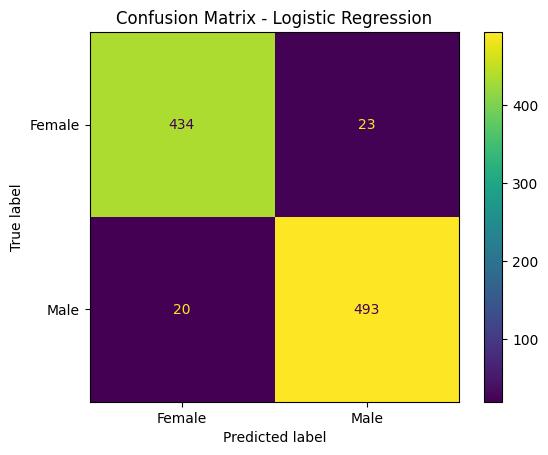

Logistic Regression: Male


In [6]:
import pandas as pd
df = pd.read_csv("C:/Users/aroma/Desktop/gender_classification.csv")
df.head()
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("\nDuplicate rows:", df.duplicated().sum())
from sklearn.preprocessing import LabelEncoder
# Encode gender (Male=1, Female=0)
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
X = df.drop("gender", axis=1)
y = df["gender"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
 # model training
from sklearn.linear_model import LogisticRegression
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
# model evalution
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
y_pred_log = log_reg.predict(X_test)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Female","Male"]))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
#External Prediction
# ------------------------------
new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]  # Example new input

# Column names must match training data
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# Predict again
log_result = log_reg.predict(new_data_df)[0]


print("Logistic Regression:", le.inverse_transform([log_result])[0])

